## Visualizations in Python
Go through analysis and visuals to gain insight on performance
Import csv and correct libs

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import statsmodels.api as sm
# from datetime import date, time

df = pd.read_csv(r'C:\Users\Kat\Documents\repos\flight-performance-analysis\clean_data\merged_flights.csv')
origin_df = pd.read_csv(r'C:\Users\Kat\Documents\repos\flight-performance-analysis\clean_data\airports_origin_us_only.csv')

### Exploratory Analysis 
1. Which months/seasons have the most delays and why (answered with correlation)? Use a bar chart for months and pie chart for season

    MONTH   TOTAL   DELAYED  DELAY_RATE
0       1  539747   95660.0   17.723118
1       2  504884   97820.0   19.374747
2       3  600872  113973.0   18.967933
3       4  583950  108455.0   18.572652
4       5  605648  135037.0   22.296284
5       6  611575  165475.0   27.057188
6       7  631428  176520.0   27.955681
7       8  602378  133299.0   22.128796
8       9  562439   92348.0   16.419203
9      10  605844  118158.0   19.503040
10     11  570550  110867.0   19.431601


C:\Users\Kat\AppData\Local\Temp\ipykernel_41268\3029576763.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


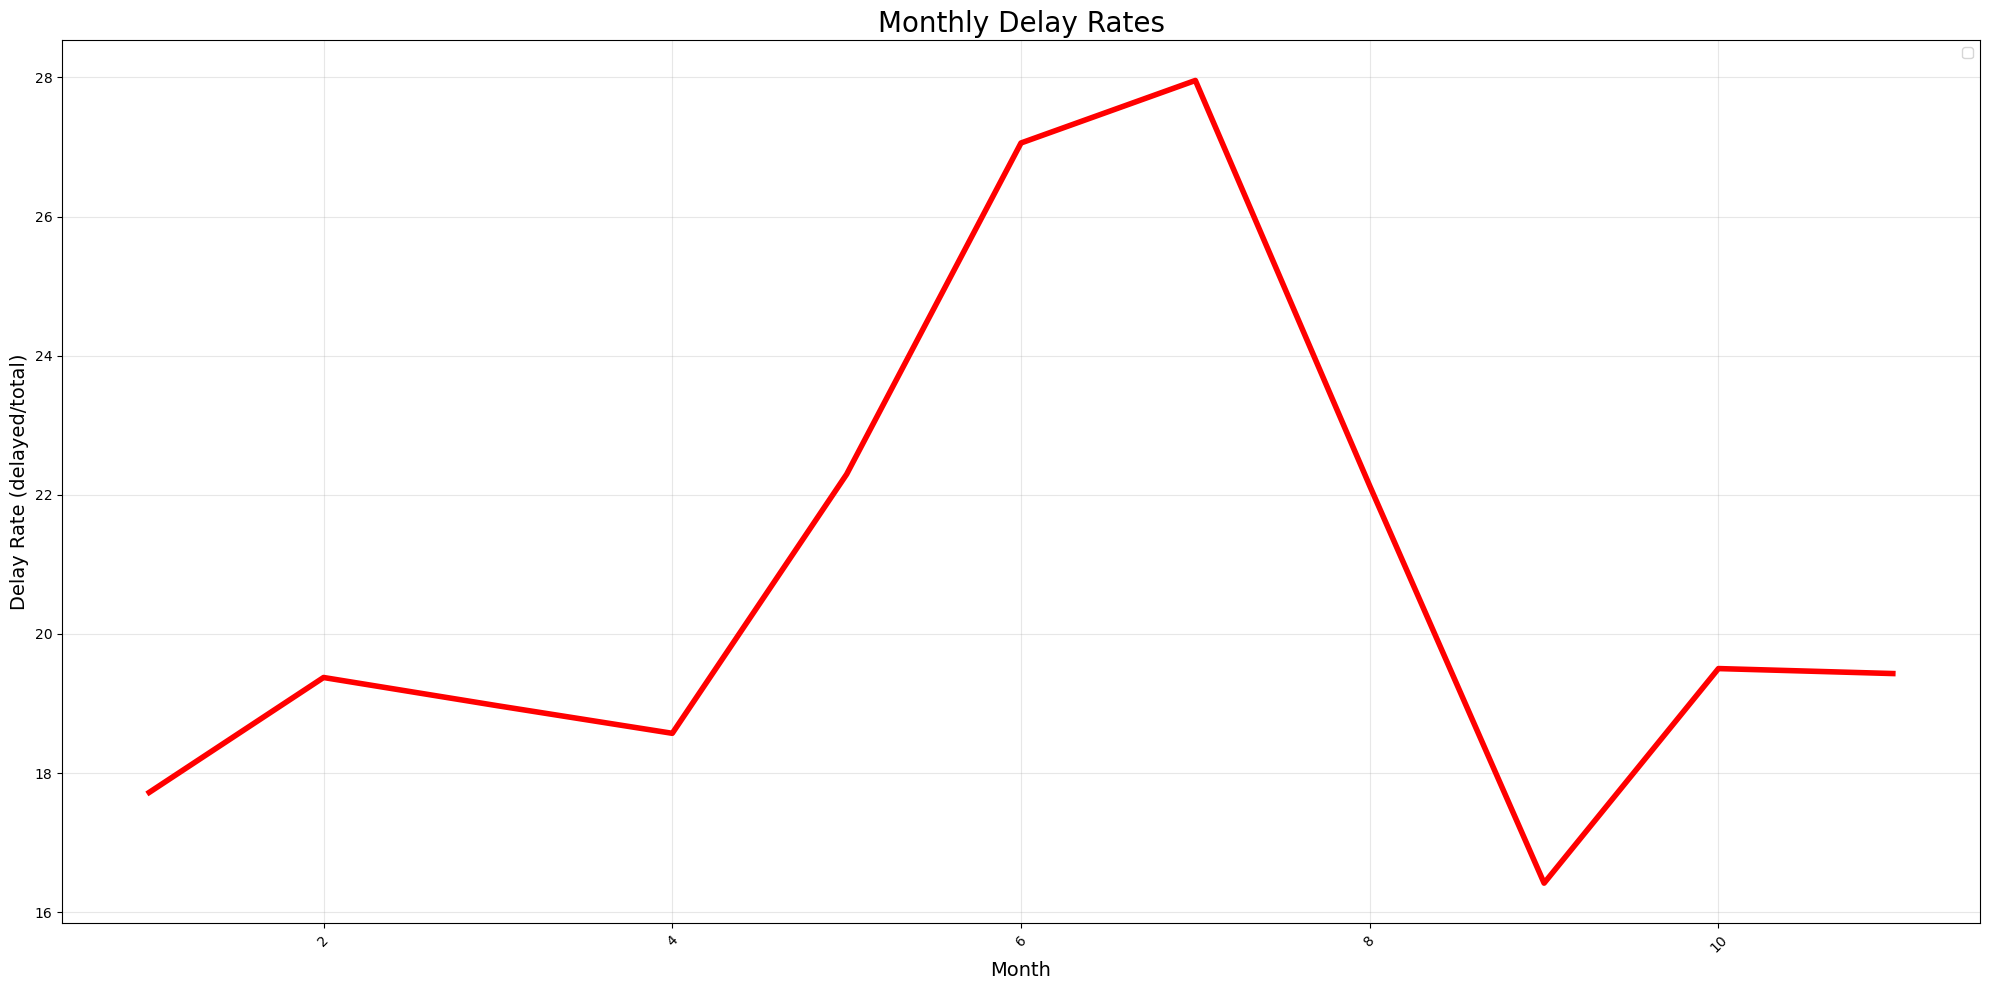

   SEASON    TOTAL   DELAYED  DELAY_RATE
0    Fall  1738833  321373.0   18.482108
1  Spring  1790470  357465.0   19.964870
2  Summer  1845381  475294.0   25.755874
3  Winter  1044631  193480.0   18.521373


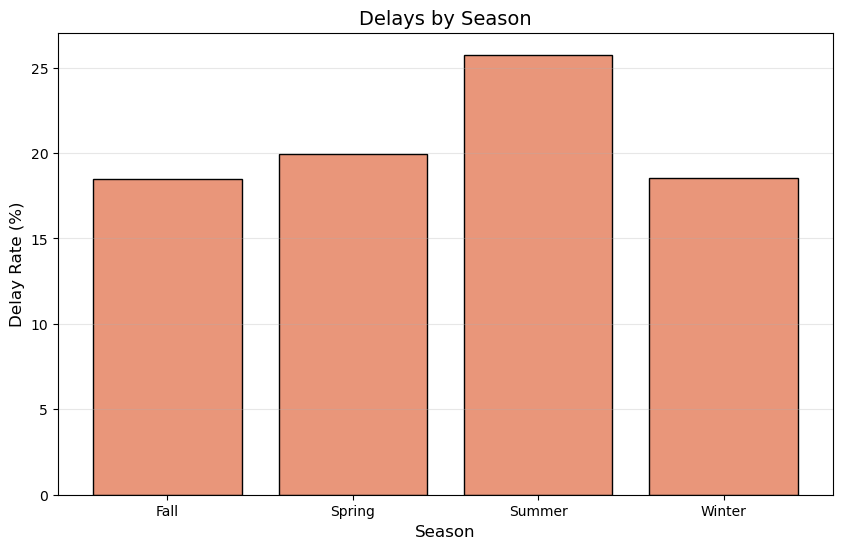

In [2]:
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])
df['MONTH'] = df['FL_DATE'].dt.month # as int

month_to_season = {
    1: "Winter",
    2: "Winter",
    3: "Spring",
    4: "Spring",
    5: "Spring",
    6: "Summer",
    7: "Summer",
    8: "Summer",
    9: "Fall",
    10: "Fall",
    11: "Fall",
    12: "Winter",
}
df["SEASON"] = df['MONTH'].map(month_to_season)

month_delays = df.groupby('MONTH')['DEP_DEL15'].agg(TOTAL="count",DELAYED="sum").reset_index().sort_values('MONTH')
month_delays['DELAY_RATE'] = month_delays['DELAYED'] / month_delays['TOTAL'] * 100
print(month_delays)


plt.figure(figsize=(20, 10))
plt.plot(month_delays['MONTH'], month_delays['DELAY_RATE'], linewidth=4, color='red', label='')
plt.title('Monthly Delay Rates', fontsize=20)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Delay Rate (delayed/total)', fontsize=14)
plt.legend()

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

season_delays = df.groupby('SEASON')['DEP_DEL15'].agg(TOTAL="count",DELAYED="sum").reset_index().sort_values('SEASON')
season_delays['DELAY_RATE'] = season_delays['DELAYED']/season_delays['TOTAL'] * 100
print(season_delays)

plt.figure(figsize=(10, 6))
plt.bar(season_delays['SEASON'], season_delays['DELAY_RATE'], color='darksalmon', edgecolor='black', alpha=1.0)

# Add labels and a title
plt.xlabel("Season", fontsize=12)
plt.ylabel("Delay Rate (%)", fontsize=12)
plt.title("Delays by Season", fontsize=14)
plt.grid(True, alpha=0.3, axis='y')

# Display the chart
plt.show()


2. Which regions have the most delays? Use a map and list from greatest to least 

Top 15 Airports with Most Delays:
      REGION    TOTAL   DELAYED  DELAY_RATE
2      South  2537106  579970.0       22.86
3       West  2020867  387155.0       19.16
0    Midwest  1081703  219753.0       20.32
1  Northeast   737718  152095.0       20.62

Total Number of Airports Analyzed: 4


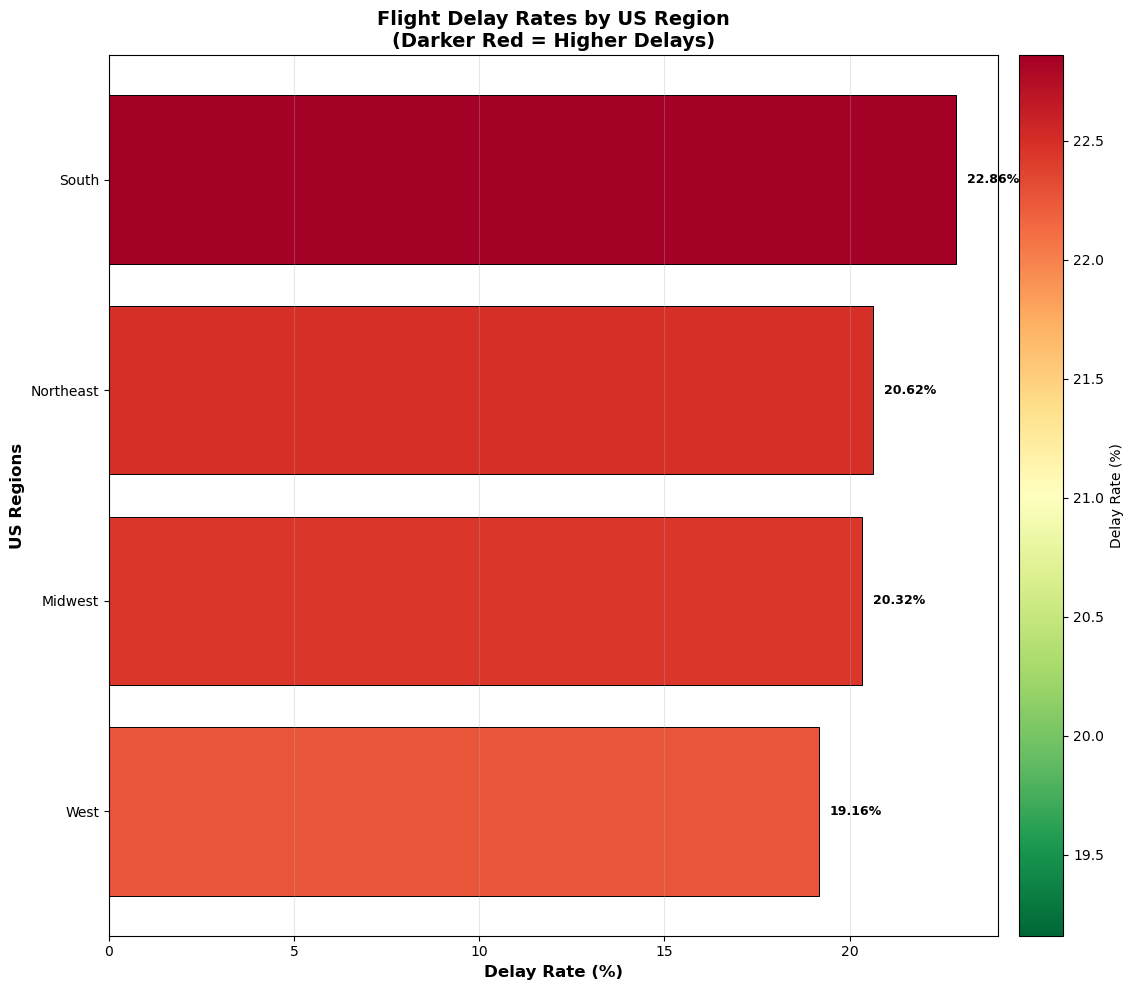

In [3]:
# analyze delays by origin airport
state_to_region = {
    # Northeast
    'CT': 'Northeast', 'ME': 'Northeast', 'MA': 'Northeast', 'NH': 'Northeast',
    'RI': 'Northeast', 'VT': 'Northeast', 'NJ': 'Northeast', 'NY': 'Northeast',
    'PA': 'Northeast',
    # Midwest
    'IL': 'Midwest', 'IN': 'Midwest', 'MI': 'Midwest', 'OH': 'Midwest',
    'WI': 'Midwest', 'IA': 'Midwest', 'KS': 'Midwest', 'MN': 'Midwest',
    'MO': 'Midwest', 'NE': 'Midwest', 'ND': 'Midwest', 'SD': 'Midwest',
    # South
    'DE': 'South', 'FL': 'South', 'GA': 'South', 'MD': 'South', 'NC': 'South',
    'SC': 'South', 'VA': 'South', 'DC': 'South', 'WV': 'South', 'AL': 'South',
    'KY': 'South', 'MS': 'South', 'TN': 'South', 'AR': 'South', 'LA': 'South',
    'OK': 'South', 'TX': 'South',
    # West
    'AZ': 'West', 'CO': 'West', 'ID': 'West', 'MT': 'West', 'NV': 'West',
    'NM': 'West', 'UT': 'West', 'WY': 'West', 'AK': 'West', 'CA': 'West',
    'HI': 'West', 'OR': 'West', 'WA': 'West',
}

origin_df['REGION'] = origin_df['state'].map(state_to_region)

df = df.merge(origin_df[['airport_id', 'REGION']], left_on='ORIGIN', right_on='airport_id', how='left')
df = df.drop(columns=['airport_id'])

region_delays = df.groupby('REGION')['DEP_DEL15'].agg(TOTAL="count", DELAYED="sum").reset_index().sort_values('DELAYED', ascending=False)
region_delays['DELAY_RATE'] = (region_delays['DELAYED'] / region_delays['TOTAL'] * 100).round(2)

print("Top 15 Airports with Most Delays:")
print(region_delays.head(15))
print(f"\nTotal Number of Airports Analyzed: {len(region_delays)}")

fig, ax = plt.subplots(figsize=(12, 10))

region_delays_sorted = region_delays.sort_values('DELAY_RATE', ascending=True)

# colormap
colors = plt.cm.RdYlGn_r(region_delays_sorted['DELAY_RATE'] / region_delays_sorted['DELAY_RATE'].max())
bars = ax.barh(region_delays_sorted['REGION'], region_delays_sorted['DELAY_RATE'], color=colors, edgecolor='black', linewidth=0.7)

# colorbar
sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn_r, norm=plt.Normalize(vmin=region_delays_sorted['DELAY_RATE'].min(), vmax=region_delays_sorted['DELAY_RATE'].max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label='Delay Rate (%)', pad=0.02)

for i, (bar, rate) in enumerate(zip(bars, region_delays_sorted['DELAY_RATE'])):
    ax.text(rate + 0.3, bar.get_y() + bar.get_height()/2, f'{rate}%', 
            va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Delay Rate (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('US Regions', fontsize=12, fontweight='bold')
ax.set_title('Flight Delay Rates by US Region\n(Darker Red = Higher Delays)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# # Additional summary statistics
# print(f"\nDelay Rate Summary:")
# print(f"Highest: {region_delays['DELAY_RATE'].max():.2f}% at {region_delays.loc[region_delays['DELAY_RATE'].idxmax(), 'ORIGIN']}")
# print(f"Lowest: {region_delays['DELAY_RATE'].min():.2f}% at {region_delays.loc[region_delays['DELAY_RATE'].idxmin(), 'ORIGIN']}")
# print(f"Average: {region_delays['DELAY_RATE'].mean():.2f}%")


### Descriptive Analysis 
1. What is the average delay time per airport? Airline? Pick the region that is busiest and focus on airlines outgoing

Top 10 airports by average delay time:
    ORIGIN  TOTAL_FLIGHTS  AVG_DELAY_MINUTES  MEDIAN_DELAY
91     DHN             52             104.48           0.0
66     CKB            194              68.42          15.0
147    HGR            294              45.24          13.0
341    USA            635              41.43           5.0
157    HTS            504              39.77           7.0
216    MGW            667              39.26           0.0
179    JST            667              37.36           0.0
297    SCK            502              36.49           1.5
152    HOB            668              33.99           0.0
176    JLN            666              33.85           0.0

Bottom 10 airports by average delay time:
    ORIGIN  TOTAL_FLIGHTS  AVG_DELAY_MINUTES  MEDIAN_DELAY
170    ITH              4               1.25           0.0
263    PQI            334               3.35           0.0
59     CDC            574               4.32           0.0
103    EKO            453        

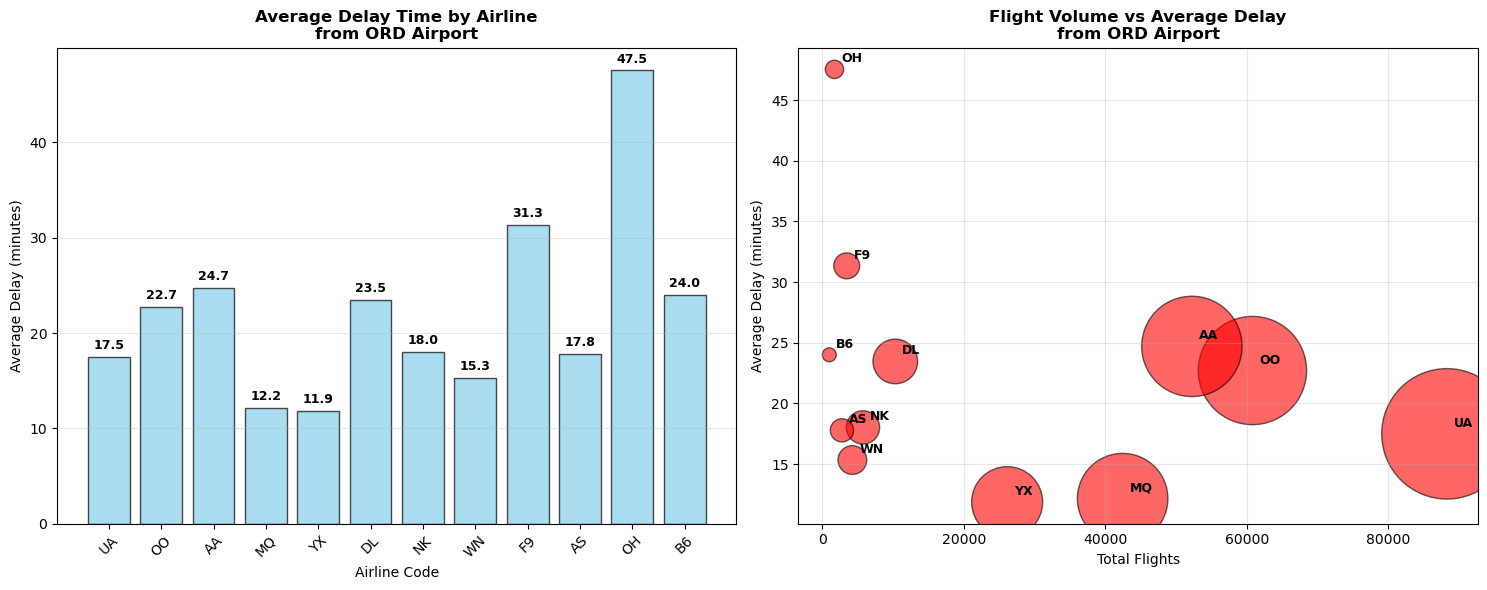


=== SUMMARY STATISTICS FOR ORD ===
Total flights: 299238
Airlines operating: 12
Average delay across all flights: 19.11 minutes
Most reliable airline: YX (11.86 min avg)
Least reliable airline: OH (47.54 min avg)


In [6]:
df['AIRLINE_CODE'] = df['FL_CODE'].str[:2]

# avg airport delays in minutes
airport_delays = df.groupby('ORIGIN')['DEP_DELAY_NEW'].agg(
    TOTAL_FLIGHTS="count",
    AVG_DELAY_MINUTES="mean",
    MEDIAN_DELAY="median",
    MAX_DELAY="max"
).reset_index().round(2)

# avg airline delays in minutes
airline_delays = df.groupby('AIRLINE_CODE')['DEP_DELAY_NEW'].agg(
    TOTAL_FLIGHTS="count",
    AVG_DELAY_MINUTES="mean",
    MEDIAN_DELAY="median",
    MAX_DELAY="max"
).reset_index().round(2)

print("Top 10 airports by average delay time:")
print(airport_delays.nlargest(10, 'AVG_DELAY_MINUTES')[['ORIGIN', 'TOTAL_FLIGHTS', 'AVG_DELAY_MINUTES', 'MEDIAN_DELAY']])
print("\nBottom 10 airports by average delay time:")
print(airport_delays.nsmallest(10, 'AVG_DELAY_MINUTES')[['ORIGIN', 'TOTAL_FLIGHTS', 'AVG_DELAY_MINUTES', 'MEDIAN_DELAY']])

print("\nTop 10 airlines by average delay time:")
print(airline_delays.nlargest(10, 'AVG_DELAY_MINUTES')[['AIRLINE_CODE', 'TOTAL_FLIGHTS', 'AVG_DELAY_MINUTES', 'MEDIAN_DELAY']])
print("\nBottom 10 airlines by average delay time:")
print(airline_delays.nsmallest(10, 'AVG_DELAY_MINUTES')[['AIRLINE_CODE', 'TOTAL_FLIGHTS', 'AVG_DELAY_MINUTES', 'MEDIAN_DELAY']])

# Find the busiest airport (most flights)
busiest_airport = airport_delays.loc[airport_delays['TOTAL_FLIGHTS'].idxmax(), 'ORIGIN']
print(f"\n=== BUSIEST AIRPORT ANALYSIS ===")
print(f"Busiest airport: {busiest_airport} with {airport_delays['TOTAL_FLIGHTS'].max()} flights")

# Analyze airlines outgoing from the busiest airport (using carrier code)
busiest_airport_data = df[df['ORIGIN'] == busiest_airport]
airline_delays_busiest = busiest_airport_data.groupby('AIRLINE_CODE')['DEP_DELAY_NEW'].agg(
    TOTAL_FLIGHTS="count",
    AVG_DELAY_MINUTES="mean",
    MEDIAN_DELAY="median"
).reset_index().round(2).sort_values('TOTAL_FLIGHTS', ascending=False)

print(f"\nAirlines operating from {busiest_airport} (sorted by flight volume):")
print(airline_delays_busiest)

# Create visualization for airlines at busiest airport
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart for average delay by airline
bars = ax1.bar(airline_delays_busiest['AIRLINE_CODE'], airline_delays_busiest['AVG_DELAY_MINUTES'],
               color='skyblue', edgecolor='black', alpha=0.7)
ax1.set_title(f'Average Delay Time by Airline\nfrom {busiest_airport} Airport', fontsize=12, fontweight='bold')
ax1.set_xlabel('Airline Code', fontsize=10)
ax1.set_ylabel('Average Delay (minutes)', fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')
ax1.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar, delay in zip(bars, airline_delays_busiest['AVG_DELAY_MINUTES']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{delay:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Scatter plot showing relationship between flight volume and delay
scatter = ax2.scatter(airline_delays_busiest['TOTAL_FLIGHTS'], airline_delays_busiest['AVG_DELAY_MINUTES'],
                     s=airline_delays_busiest['TOTAL_FLIGHTS']/10, alpha=0.6, c='red', edgecolors='black')

# Add airline labels to points
for i, row in airline_delays_busiest.iterrows():
    ax2.annotate(row['AIRLINE_CODE'],
                (row['TOTAL_FLIGHTS'], row['AVG_DELAY_MINUTES']),
                xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')

ax2.set_title(f'Flight Volume vs Average Delay\nfrom {busiest_airport} Airport', fontsize=12, fontweight='bold')
ax2.set_xlabel('Total Flights', fontsize=10)
ax2.set_ylabel('Average Delay (minutes)', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print(f"\n=== SUMMARY STATISTICS FOR {busiest_airport} ===")
print(f"Total flights: {busiest_airport_data.shape[0]}")
print(f"Airlines operating: {airline_delays_busiest.shape[0]}")
print(f"Average delay across all flights: {busiest_airport_data['DEP_DELAY_NEW'].mean():.2f} minutes")
print(f"Most reliable airline: {airline_delays_busiest.loc[airline_delays_busiest['AVG_DELAY_MINUTES'].idxmin(), 'AIRLINE_CODE']} ({airline_delays_busiest['AVG_DELAY_MINUTES'].min():.2f} min avg)")
print(f"Least reliable airline: {airline_delays_busiest.loc[airline_delays_busiest['AVG_DELAY_MINUTES'].idxmax(), 'AIRLINE_CODE']} ({airline_delays_busiest['AVG_DELAY_MINUTES'].max():.2f} min avg)")
